<a href="https://colab.research.google.com/github/Murcha1990/ML_Course_PT/blob/main/Lecture7_LLM/LLM_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Доступ к LLM по API и базовый инференс

# Шаг 1: Получаем доступ к LLM по API и учимся с ней общаться

## Будем работать с моделями (LLM) через API OpenRouter

OPENROUTER_TOKEN возьмем с сайта openrouter в личном кабинете.

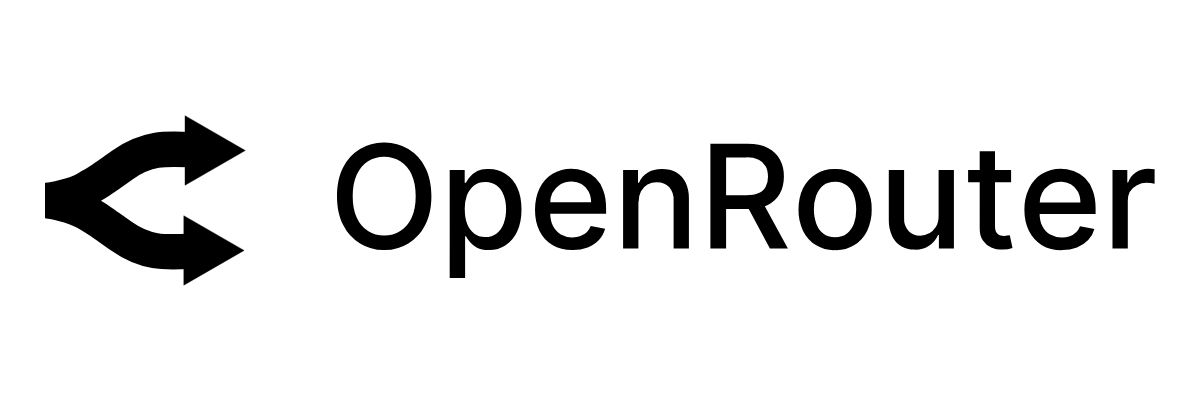

In [ ]:
!pip install langchain langchain-openai langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.0/503.0 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: openai
    Found existing installation: openai 2.24.0
    Uninstalling openai-2.24.0:
      Successfully uninstalled openai-2.24.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.16
    Uninstalling langchain-core-1.2.16:
  

Подключимся к модели DeepSeek

In [ ]:
OPENROUTER_TOKEN = ""

In [ ]:
from langchain_openai import ChatOpenAI

deepseek_llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model = "stepfun/step-3.5-flash:free"
#    model="deepseek/deepseek-r1-0528:free"
)

deepseek_response = deepseek_llm.invoke("Привет! Как твои дела?").content
print(deepseek_response)

Привет! У меня всё отлично, спасибо! 😊 Я здесь, чтобы помочь тебе с любыми вопросами или задачами. Как я могу быть полезен сегодня?


Пообщаемся с моделью и выясним, есть ли у нее память?

In [ ]:
question1 = "Сколько лап у паука?"
additional_question = "А зубов?"

print(question1)
print(deepseek_llm.invoke(question1).content)
print(additional_question)
print(deepseek_llm.invoke(additional_question).content)

Сколько лап у паука?
У паука **8 лап**. Это один из ключевых признаков, отличающий паукообразных (включая пауков, скорпионов, клещей) от насекомых (у которых 6 лап).
А зубов?
Это отличный и очень важный вопрос! 😁 Без контекста «зубов» можно интерпретировать по-разному. Вот основные направления, которые могут вас интересовать:

### 1. **Уход и профилактика**
   *   **Чистка:** Как правильно чистить? Нужна ли нить/ершики?
   *   **Паста:** Какую выбрать (для чувствительных, отбеливающую и т.д.)?
   *   **Осмотр:** Как часто ходить к стоматологу?

### 2. **Лечение и проблемы**
   *   **Кариес:** Почему возникает, как лечить, как предотвратить?
   *   **Десны:** Как бороться с воспалением (гингивитом, пародонтитом)?
   *   **Клиренс (зубной камень):** Что это и почему его нужно удалять?
   *   **Брекеты/коррекция:** В каком возрасте, какие системы, сколько стоит?

### 3. **Эстетика и восстановление**
   *   **Отбеливание:** Методы, эффективность, безопасность.
   *   **Длявиниры/люминиры:*

Оформим диалог красиво

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

question1_message = HumanMessage(content=question1)
additional_question_message = HumanMessage(content=additional_question)

answer1_message = AIMessage(content=deepseek_llm.invoke([question1_message]).content)
answer2_message = AIMessage(content=deepseek_llm.invoke([additional_question_message]).content)

question1_message.pretty_print()
answer1_message.pretty_print()
additional_question_message.pretty_print()
answer2_message.pretty_print()

================================ Human Message =================================

Сколько лап у паука?
================================== Ai Message ==================================

У паука **8 лап**.  

Пауки относятся к классу **паукообразных** (Arachnida), для которых характерно наличие **8 ног** (в отличие от насекомых, у которых 6 ног).  

Кроме того, у пауков есть две дополнительные пары придатков перед головогрудью — **педипальпы**. Они выполняют функцию ощупания, захвата пищи и у самцов используются для передачи спермы, но **не считаются лапами**.  

Таким образом, если видите 8 ходильных конечностей — это точно паук (или другой представитель паукообразных: скорпион, клещ и т.д.).
================================ Human Message =================================

А зубов?
================================== Ai Message ==================================

Отличный вопрос! 😊 Если говорить коротко и по делу:

**«А зубов?»** — это, скорее всего, уточняющий вопрос в контексте чего-то

Памяти - нет. Организуем ее самостоятельно!

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

dialogue = []
dialogue.append(question1_message)
dialogue.append(AIMessage(content=deepseek_llm.invoke(dialogue).content))
dialogue.append(additional_question_message)
dialogue.append(AIMessage(content=deepseek_llm.invoke(dialogue).content))

for phrase in dialogue:
    phrase.pretty_print()

================================ Human Message =================================

Сколько лап у паука?
================================== Ai Message ==================================

У паука **8 лап** (или ног).  

Это характерное признак всех паукообразных (включая скорпионов, клещей и другие). Для сравнения:
- Насекомые имеют 6 ног.
- Осьминоги, кальмары и другие головоногие моллюски — 10 ног (8 рук/щупалец + 2 особых держащих щупальца).

Ноги паука соединены с головогрудью (pereiopods) и служат для перемещения, охоты, чувствительности к вибрациям и даже в некоторых видах для создания звука (стрекотания).
================================ Human Message =================================

А зубов?
================================== Ai Message ==================================

У пауков **нет зубов** в привычном для нас понимании (как у млекопитающих, рыб или некоторых рептилий).

Вместо зубов у них есть специальные хитиновые структуры:

1.  **Хелицеры** (или «клыки»): Это пара усиков